In [1]:
import os
os.chdir("/Users/gonzalopozo/Documents/Edinburgh/master/Thesis/Diss")
import numpy as np
from ball_on_plate.envs.ball_on_plate import BallOnPlateEnv
import matplotlib
import pandas as pd

%matplotlib inline
#matplotlib.use("Agg")


import matplotlib.pyplot as plt

In [2]:

class BallPDController:

    def __init__(self,kp=20.0,kd=5.0,max_torque=20.0):

        self.kp = kp
        self.kd = kd
        self.max_torque = max_torque

    def __call__(self, state):

        x = state[0]
        y = state[1]

        x_dot = state[2]
        y_dot = state[3]

        # Desired tilt correction
        roll_command = (self.kp*x + self.kd*x_dot)
        pitch_command = (self.kp*y + self.kd*y_dot)

        action = np.array([roll_command,pitch_command])

        return np.clip(action,-self.max_torque,self.max_torque)
        
controller = BallPDController(kp=2,kd=1,max_torque=10.0)

env = BallOnPlateEnv(render_mode=None)

In [3]:


def physics_check_action(s_t):
    return controller(s_t)

def predict_change(state,dt):
    g = 9.81
    C = 5.0 / 7.0 * g
    
    x, y, x_dot, y_dot, alpha, beta, _, _ = state

    x_ddot = -C * alpha
    y_ddot = -C * beta

    dx = x_dot + dt * x_ddot
    dy = y_dot + dt * y_ddot
    dx_dot = x_ddot
    dy_dot = y_ddot

    return {"x_dot":dx,"y_dot":dy,"x_ddot":dx_dot,"y_ddot": dy_dot}

def run_physics_check(num_episodes=100,max_steps=5000):

    records=[]

    truncations = 0
    terminations = 0

    for episode in range(num_episodes):

        s_t, info = env.reset()

        for step in range(max_steps):
            a_t = physics_check_action(s_t)
            s_prime, reward, terminated, truncated, info = env.step(a_t)

            env.render()
            if info.get("ball_lost", False):
                break
            
            hat = predict_change(s_t,env.dt)

            if terminated:
                terminations+=1
                break
            elif truncated:
                truncations+=1
                break

            record= {
                "episode": episode,
                "step": step,
                "dt": env.dt,

                # state
                "x": s_t[0],
                "y": s_t[1],
                "x_dot": s_t[2],
                "y_dot": s_t[3],
                "alpha": s_t[4],
                "beta": s_t[5],
                "alpha_dot": s_t[6],
                "beta_dot": s_t[7],

                # state_prime
                "x_prime": s_prime[0],
                "y_prime": s_prime[1],
                "x_dot_prime": s_prime[2],
                "y_dot_prime": s_prime[3],

                # action
                "roll_torque": a_t[0],
                "pitch_torque": a_t[1],

                # real dts
                "x_dot_real": s_prime[2],
                "y_dot_real": s_prime[3],

                # predicted ddts
                "x_ddot_pred": hat["x_ddot"],
                "y_ddot_pred": hat["y_ddot"],
                # predicted dts
                "x_dot_pred": hat["x_dot"],
                "y_dot_pred": hat["y_dot"],
                }
            
            records.append(record)
            s_t = s_prime
    df= pd.DataFrame(records)
    return df

df = run_physics_check()


In [4]:
# Data analysis

df["x_ddot_real"] = (df["x_dot_prime"] - df["x_dot"])/df["dt"]

df["y_ddot_real"] = (df["y_dot_prime"] - df["y_dot"])/df["dt"]

df["x_ddot_error"] = df["x_ddot_real"] - df["x_ddot_pred"]

df["y_ddot_error"] = df["y_ddot_real"] - df["y_ddot_pred"]

df["x_dot_error"] = df["x_dot_prime"] - df["x_dot_pred"]

df["y_dot_error"] = df["y_dot_prime"] - df["y_dot_pred"]

df["x_ddot_abs_error"] = abs(df["x_ddot_error"])
df["y_ddot_abs_error"] = abs(df["y_ddot_error"])

df["x_dot_abs_error"] = abs(df["x_dot_error"])
df["y_dot_abs_error"] = abs(df["y_dot_error"])

df["ddot_error"] = np.sqrt(df["x_ddot_error"]**2 +df["y_ddot_error"]**2)
df["dot_error"] = np.sqrt(df["x_dot_error"]**2 +df["y_dot_error"]**2)

In [5]:
def print_stats(name, series):

        print(f"\n{name}")
        print("----------------")
        print(f"Mean: {series.mean():.6f}")
        print(f"Std : {series.std():.6f}")
        print(f"Max : {series.max():.6f}")
        print(f"95% : {series.quantile(0.95):.6f}")
        print(f"99% : {series.quantile(0.99):.6f}")


print_stats("xddot error", df["x_ddot_abs_error"])
print_stats("yddot error", df["y_ddot_abs_error"])

print_stats("xdot error", df["x_dot_abs_error"])
print_stats("ydot error", df["y_dot_abs_error"])

print_stats("Acceleration vector error", df["ddot_error"])
print_stats("Velocity vector error", df["dot_error"])

print("Mean signed acceleration error")
print("------------------------------")
print(df[["x_ddot_error","y_ddot_error"]].mean())



xddot error
----------------
Mean: 2.303668
Std : 4.302405
Max : 163.469308
95% : 5.434013
99% : 19.572495

yddot error
----------------
Mean: 2.348193
Std : 3.224935
Max : 115.231570
95% : 6.050042
99% : 15.302242

xdot error
----------------
Mean: 0.004607
Std : 0.008605
Max : 0.326939
95% : 0.010868
99% : 0.039145

ydot error
----------------
Mean: 0.004696
Std : 0.006450
Max : 0.230463
95% : 0.012100
99% : 0.030604

Acceleration vector error
----------------
Mean: 3.518366
Std : 5.229997
Max : 200.001323
95% : 9.455385
99% : 24.333244

Velocity vector error
----------------
Mean: 0.007037
Std : 0.010460
Max : 0.400003
95% : 0.018911
99% : 0.048666
Mean signed acceleration error
------------------------------
x_ddot_error    0.065885
y_ddot_error   -0.046747
dtype: float64


In [6]:

#Correlations
variables = ["x_dot","y_dot","alpha","beta","roll_torque","pitch_torque"]
errors = ["x_ddot_error","y_ddot_error","ddot_error","dot_error"]
corr = df[variables + errors].corr()
print(corr[errors].loc[variables])

#Angles vs ddot

x_mask = abs(df["alpha"]) > 0.02
x_ratio = (df.loc[x_mask,"x_ddot_real"] /df.loc[x_mask,"alpha"])#Should be around -5/7 * g
y_mask = abs(df["beta"]) > 0.02
y_ratio = (df.loc[y_mask,"y_ddot_real"] /df.loc[y_mask,"beta"])#Should be around -5/7 * g
print(x_ratio.describe())
print(y_ratio.describe())

# Different errors for different speeds?
df["dot"] = np.sqrt(df["x_dot"]**2+df["y_dot"]**2)
print(df.groupby(pd.qcut(df["dot"],4))["ddot_error"].mean())

              x_ddot_error  y_ddot_error  ddot_error  dot_error
x_dot            -0.079576     -0.016505    0.009927   0.009927
y_dot             0.028578     -0.082312    0.000472   0.000472
alpha             0.152871      0.001441    0.023250   0.023250
beta             -0.009395      0.252071   -0.059750  -0.059750
roll_torque      -0.038085     -0.013689    0.010830   0.010830
pitch_torque      0.024153      0.012288   -0.020482  -0.020482
count    54420.000000
mean        -8.473723
std         21.931910
min       -910.894034
25%        -10.306919
50%         -5.113383
75%          0.000000
max       1814.903485
dtype: float64
count    55421.000000
mean        -8.312046
std         14.306798
min       -286.086638
25%         -9.901936
50%         -5.813759
75%          0.000000
max        212.688021
dtype: float64
dot
(0.00135, 0.241]    1.975419
(0.241, 0.389]      3.405499
(0.389, 0.699]      3.740986
(0.699, 1.957]      4.968233
Name: ddot_error, dtype: float64


/var/folders/27/gl2xh2rx7_z3z7jh3h2d_dsc0000gn/T/ipykernel_73543/1262420831.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df["dot"],4))["ddot_error"].mean())


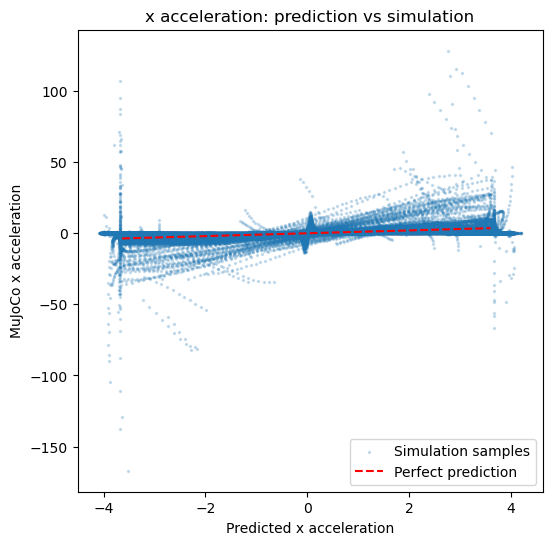

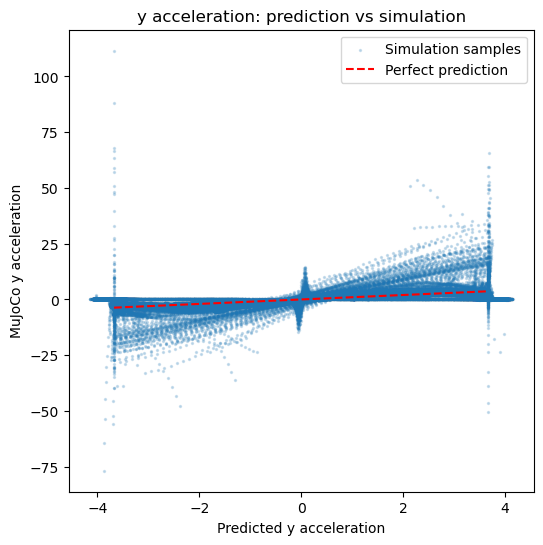

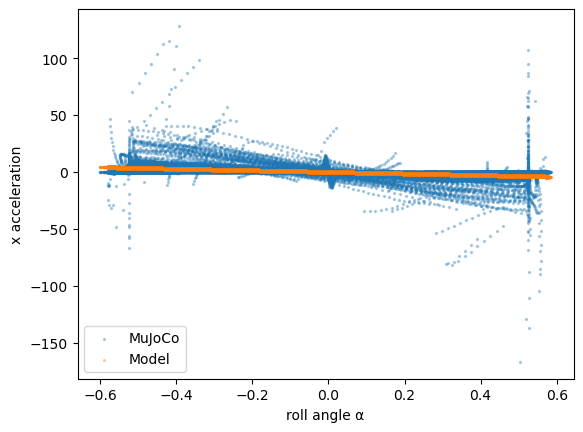

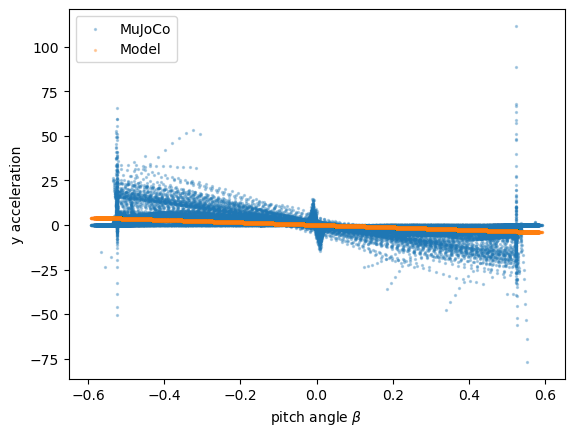

In [7]:
#---------------------------------
#Plots
#---------------------------------

## Predicted ddot vs real ddot (x)
plt.figure(figsize=(6,6))
plt.scatter(df["x_ddot_pred"],df["x_ddot_real"],s=2,alpha=0.2,label="Simulation samples")
lims = [min(df["x_ddot_pred"].quantile(0.1), df["x_ddot_real"].quantile(0.1)),max(df["x_ddot_pred"].quantile(0.9), df["x_ddot_real"].quantile(0.9))]
plt.plot(lims, lims, "--",label="Perfect prediction", color='red')
plt.xlabel("Predicted x acceleration")
plt.ylabel("MuJoCo x acceleration")
plt.title("x acceleration: prediction vs simulation")
plt.legend()
plt.show()

# Predicted ddot vs real ddot (y)
plt.figure(figsize=(6,6))
plt.scatter(df["y_ddot_pred"],df["y_ddot_real"],s=2,alpha=0.2,label="Simulation samples")
lims = [min(df["y_ddot_pred"].quantile(0.1), df["y_ddot_real"].quantile(0.1)),max(df["y_ddot_pred"].quantile(0.9), df["y_ddot_real"].quantile(0.9))]
plt.plot(lims, lims, "--",label="Perfect prediction", color='red')
plt.xlabel("Predicted y acceleration")
plt.ylabel("MuJoCo y acceleration")
plt.title("y acceleration: prediction vs simulation")
plt.legend()
plt.show()

#ddot vs angle (x,alpha)
plt.scatter(df["alpha"],df["x_ddot_real"],s=2,alpha=0.3,label="MuJoCo")
plt.scatter(df["alpha"],df["x_ddot_pred"],s=2,alpha=0.3,label="Model")
plt.xlabel("roll angle α")
plt.ylabel("x acceleration")
plt.legend()
plt.show()

#ddot vs angle (y,beta)
plt.scatter(df["beta"],df["y_ddot_real"],s=2,alpha=0.3,label="MuJoCo")
plt.scatter(df["beta"],df["y_ddot_pred"],s=2,alpha=0.3,label="Model")
plt.xlabel("pitch angle $\\beta$")
plt.ylabel("y acceleration")
plt.legend()
plt.show()





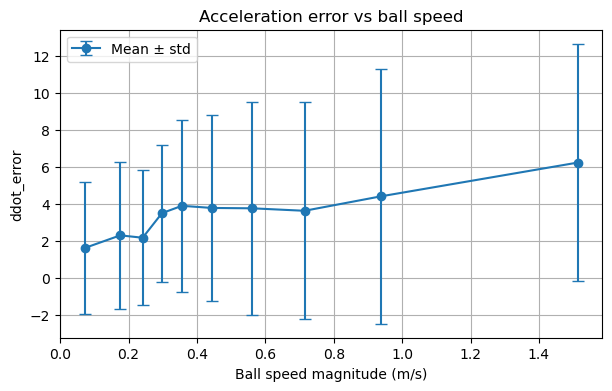

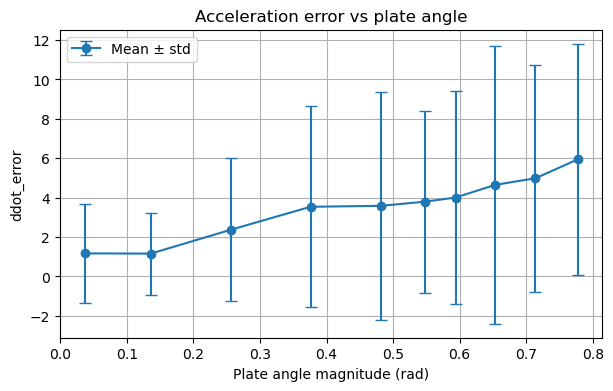

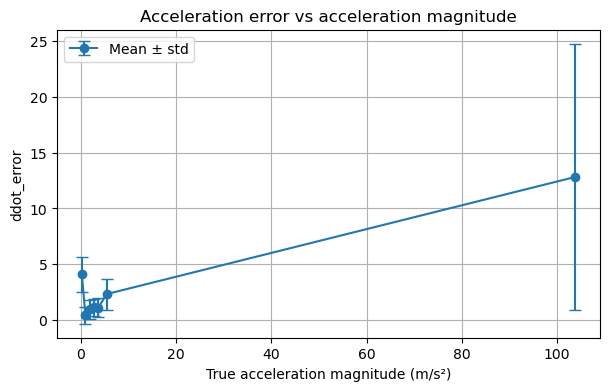

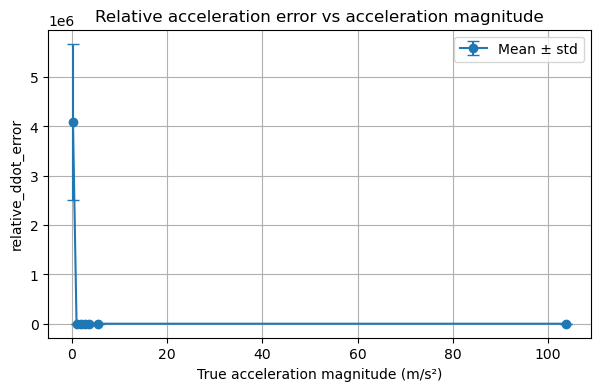

In [8]:
# =====================================================
# Error analysis using buckets
# =====================================================

def plot_error_by_bucket(df, variable, error, bins=10, xlabel="", title=""):

    temp = df.copy()

    # Divide into quantile buckets
    temp["bucket"] = pd.qcut(
        temp[variable],
        bins,
        duplicates="drop"
    )

    grouped = temp.groupby(
        "bucket",
        observed=True
    )[error].agg(
        ["mean", "std", "count"]
    )

    # Compute bucket centers
    centers = [interval.mid for interval in grouped.index]

    plt.figure(figsize=(7,4))

    plt.errorbar(
        centers,
        grouped["mean"],
        yerr=grouped["std"],
        fmt="o-",
        capsize=4,
        label="Mean ± std"
    )

    plt.xlabel(xlabel)
    plt.ylabel(error)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


# -----------------------------------------------------
# Error vs ball speed
# -----------------------------------------------------

df["ball_speed"] = np.sqrt(
    df["x_dot"]**2 + df["y_dot"]**2
)

plot_error_by_bucket(
    df,
    variable="ball_speed",
    error="ddot_error",
    bins=10,
    xlabel="Ball speed magnitude (m/s)",
    title="Acceleration error vs ball speed"
)


# -----------------------------------------------------
# Error vs plate angle magnitude
# -----------------------------------------------------

df["angle_mag"] = np.sqrt(
    df["alpha"]**2 + df["beta"]**2
)

plot_error_by_bucket(
    df,
    variable="angle_mag",
    error="ddot_error",
    bins=10,
    xlabel="Plate angle magnitude (rad)",
    title="Acceleration error vs plate angle"
)


# -----------------------------------------------------
# Error vs true acceleration magnitude
# -----------------------------------------------------

df["accel_mag"] = np.sqrt(
    df["x_ddot_real"]**2 + df["y_ddot_real"]**2
)

plot_error_by_bucket(
    df,
    variable="accel_mag",
    error="ddot_error",
    bins=10,
    xlabel="True acceleration magnitude (m/s²)",
    title="Acceleration error vs acceleration magnitude"
)


# -----------------------------------------------------
# Relative acceleration error
# -----------------------------------------------------

df["relative_ddot_error"] = (
    df["ddot_error"] /
    (df["accel_mag"] + 1e-6)
)


plot_error_by_bucket(
    df,
    variable="accel_mag",
    error="relative_ddot_error",
    bins=10,
    xlabel="True acceleration magnitude (m/s²)",
    title="Relative acceleration error vs acceleration magnitude"
)

In [23]:
def plot_rollout_prediction(df, pred, episode_id=1,H=20):

    episode = df[df["episode"] == episode_id].reset_index(drop=True)

    t = np.arange(len(episode))

    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

    # x
    axs[0,0].plot(t, episode["x"], label="MuJoCo", linewidth=2)
    axs[0,0].plot(t, pred[:,0], label="Model", linewidth=2)
    axs[0,0].set_ylabel("x (m)")
    axs[0,0].set_title("Ball x position")
    axs[0,0].legend()

    # y
    axs[0,1].plot(t, episode["y"], label="MuJoCo", linewidth=2)
    axs[0,1].plot(t, pred[:,1], label="Model", linewidth=2)
    axs[0,1].set_ylabel("y (m)")
    axs[0,1].set_title("Ball y position")
    axs[0,1].legend()

    # x velocity
    axs[1,0].plot(t, episode["x_dot"], label="MuJoCo", linewidth=2)
    axs[1,0].plot(t, pred[:,2], label="Model", linewidth=2)
    axs[1,0].set_ylabel("x velocity (m/s)")
    axs[1,0].set_xlabel("Time step")
    axs[1,0].set_title("Ball x velocity")
    axs[1,0].legend()

    # y velocity
    axs[1,1].plot(t, episode["y_dot"], label="MuJoCo", linewidth=2)
    axs[1,1].plot(t, pred[:,3], label="Model", linewidth=2)
    axs[1,1].set_ylabel("y velocity (m/s)")
    axs[1,1].set_xlabel("Time step")
    axs[1,1].set_title("Ball y velocity")
    axs[1,1].legend()


KeyError: 'x_dot'

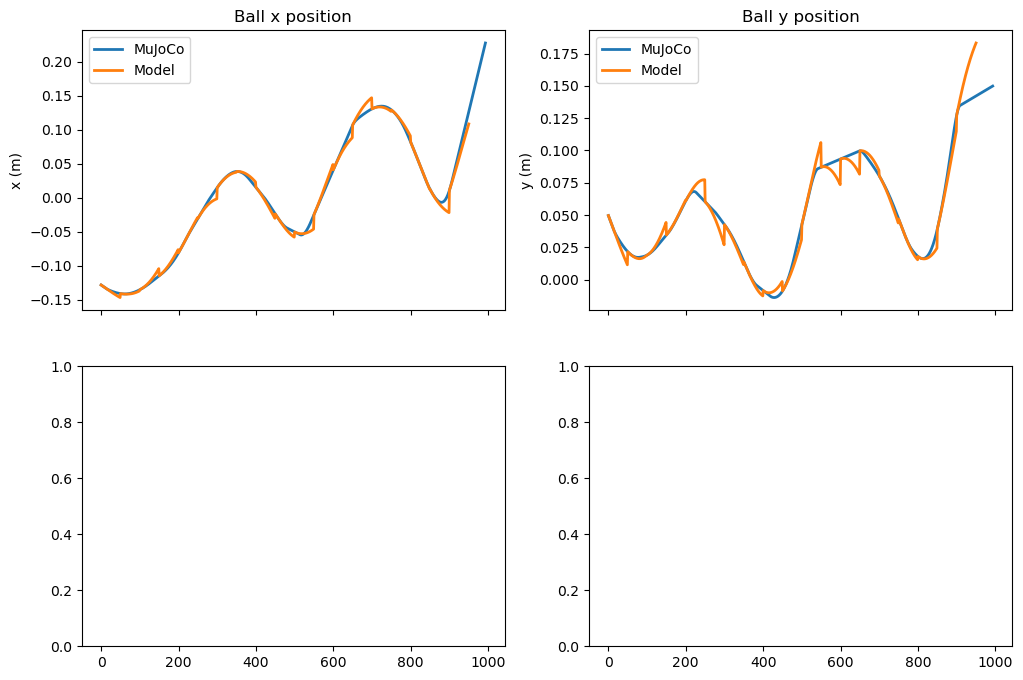

In [25]:
# 1 epsidoe prediction over horizon=H
H = 50
ep_id = 1
episode = df[df["episode"] == ep_id].reset_index(drop=True)
N = len(episode)
pred = np.full((N,4), np.nan)
for start in range(0, N - H, H):
    
    hat_state = np.array([
        episode.loc[start, "x"],
        episode.loc[start, "y"],
        episode.loc[start, "xdot"],
        episode.loc[start, "ydot"],
        episode.loc[start, "alpha"],
        episode.loc[start, "beta"],
        episode.loc[start,"alphadot"],
        episode.loc[start,"betadot"]
        ])

    pred[start] = hat_state[:4]

    for k in range(H):
        hat_d = predict_change(hat_state, env.dt)
        pred[start + k + 1] = np.array([hat_d["x_dot"],hat_d["y_dot"],hat_d["x_ddot"],hat_d["y_ddot"]]) * env.dt + hat_state[:4]
        hat_state = np.array([
        pred[start + k + 1][0],
        pred[start + k + 1][1],
        pred[start + k + 1][2],
        pred[start + k + 1][3],
        episode.loc[start + k + 1, "alpha"],
        episode.loc[start + k + 1, "beta"],
        episode.loc[start + k + 1, "alphadot"],
        episode.loc[start + k + 1, "betadot"],])


plot_rollout_prediction(df, pred, episode_id=1,H=H)

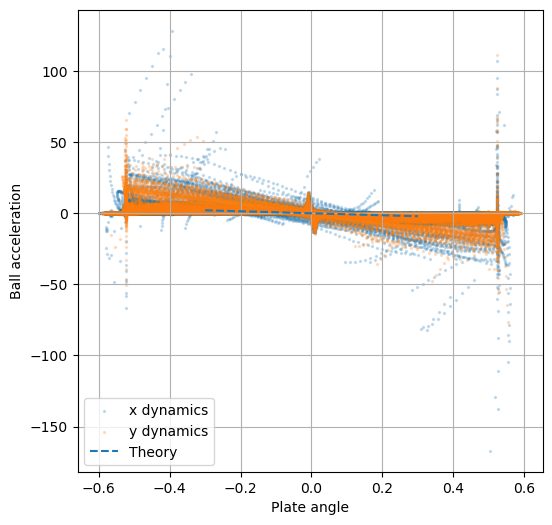

In [11]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["alpha"],
    df["x_ddot_real"],
    s=2,
    alpha=0.2,
    label="x dynamics"
)

plt.scatter(
    df["beta"],
    df["y_ddot_real"],
    s=2,
    alpha=0.2,
    label="y dynamics"
)

theta = np.linspace(-0.3,0.3,100)

plt.plot(
    theta,
    -5/7*9.81*theta,
    "--",
    label="Theory"
)

plt.xlabel("Plate angle")
plt.ylabel("Ball acceleration")
plt.legend()
plt.grid()
plt.show()

## This is once having built the MPC, to check full prediction model

In [15]:

import os
os.chdir("/Users/gonzalopozo/Documents/Edinburgh/master/Thesis/Diss")
import numpy as np
from ball_on_plate.envs.ball_on_plate import BallOnPlateEnv
from ball_on_plate.dynamics.learn_plate_dynamics import BallPDController
import pandas as pd
from joblib import load




class ExpertMPC:
    def __init__(self, env, plate_models, H=10, max_torque=10, plate_joint_limit=np.deg2rad(30), max_iters=10, x_target = np.zeros(8)):

        self.H = H  # Horizon length
        self.dt= env.dt
        self.plate_models = plate_models
        self.max_torque = max_torque
        self.plate_joint_limit = plate_joint_limit
        self.max_iters = max_iters
        self.x_target = x_target

        # Q, R from provided cost function parameters

        self.Q = np.diag([10,10, 2, 2, 1,1,0,0])
        self.R = np.diag([0.1,0.1])


        # Warm start buffer
        self.U_guess = np.zeros((self.H, 2))
    
    def predict_next_state(self, state, action):

        dt = self.dt
        
        
        x,y,xd,yd,alpha,beta,alphad,betad = state

        tau_alpha, tau_beta = action

        # plate dynamics

        roll_model , pitch_model = self.plate_models

        alphadd = (roll_model.intercept_ + roll_model.coef_[0] * tau_alpha + roll_model.coef_[1] * alpha + roll_model.coef_[2] * alphad)

        betadd = (pitch_model.intercept_ + pitch_model.coef_[0] * tau_beta + pitch_model.coef_[1] * beta + pitch_model.coef_[2] * betad)

        # ball dynamics
        g = 9.81
        C = 5/7*g

        xdd = -C *alpha
        ydd = -C *beta

        # Euler integration
        xd_next = xd + dt * xdd
        yd_next = yd + dt * ydd

        x_next = x + dt * xd_next
        y_next = y + dt * yd_next

        alphad_next = alphad + dt * alphadd
        betad_next  = betad  + dt * betadd

        alpha_next = alpha + dt * alphad_next
        beta_next  = beta  + dt * betad_next

        # Respect plate joint limits
        plate_joint_limit = self.plate_joint_limit
        alpha_next = np.clip(alpha_next, -plate_joint_limit, plate_joint_limit)
        beta_next = np.clip(beta_next, -plate_joint_limit, plate_joint_limit) 

        alphad_next = np.where(((alpha_next >= plate_joint_limit) & (alphad_next > 0)) | ((alpha_next <= -plate_joint_limit) & (alphad_next < 0)), 0.0, alphad_next,)
        betad_next  = np.where(((beta_next  >= plate_joint_limit) & (betad_next  > 0)) | ((beta_next  <= -plate_joint_limit) & (betad_next  < 0)), 0.0, betad_next,)

        return np.array([x_next, y_next, xd_next, yd_next, alpha_next, beta_next, alphad_next, betad_next])

    def get_jacobians(self):
        """
        Analytic Jacobians of predict_next_state().
        Clipping is ignored.
        """

        roll_model , pitch_model = self.plate_models
        dt = self.dt

        C = 5.0 / 7.0 * 9.81
        
        ar = roll_model.coef_
        ap = pitch_model.coef_

        # roll model:
        # alphadd = b + ar[0]*tau + ar[1]*alpha + ar[2]*alphad

        # pitch model:
        # betadd = b + ap[0]*tau + ap[1]*beta + ap[2]*betad

        A = np.eye(8)

        # --------------------------------------------------
        # Ball
        # --------------------------------------------------

        # x
        A[0,2] += dt
        A[0,4] += -C * dt**2

        # y
        A[1,3] += dt
        A[1,5] += -C * dt**2

        # xdot
        A[2,4] += -C * dt

        # ydot
        A[3,5] += -C * dt

        # --------------------------------------------------
        # Plate
        # --------------------------------------------------

        # alpha
        A[4,4] += ar[1] * dt**2
        A[4,6] += dt + ar[2] * dt**2

        # beta
        A[5,5] += ap[1] * dt**2
        A[5,7] += dt + ap[2] * dt**2

        # alphadot
        A[6,4] += ar[1] * dt
        A[6,6] += ar[2] * dt

        # betadot
        A[7,5] += ap[1] * dt
        A[7,7] += ap[2] * dt

        # --------------------------------------------------
        # Action Jacobian
        # --------------------------------------------------

        B = np.zeros((8,2))

        # roll torque
        B[4,0] = ar[0] * dt**2
        B[6,0] = ar[0] * dt

        # pitch torque
        B[5,1] = ap[0] * dt**2
        B[7,1] = ap[0] * dt

        return A, B

    def solve_ilqr(self, x0, U_init):
        """The iLQR Solver"""
        U = U_init.copy()
        X = np.zeros((self.H + 1, 8))
        X[0] = x0
        
        # Initial Rollout
        for t in range(self.H):
            X[t+1] = self.predict_next_state(X[t], U[t])
            
        for _ in range(self.max_iters):
            # Backward Pass
            ks = [np.zeros(2) for _ in range(self.H)]
            Ks = [np.zeros((2, 8)) for _ in range(self.H)] 
            
            # Terminal Value Function derivatives
            Vx = self.Q @ (X[-1]-self.x_target)
            Vxx = self.Q

            
            for t in reversed(range(self.H)):
                A, B = self.get_jacobians()

                # Gradients of the cost
                lx = 2*self.Q @ (X[t]-self.x_target)
                lu = 2*self.R @ U[t]
                lxx =  2*self.Q
                luu =  2*self.R
                lux = np.zeros((2, 8))

                ### FILL IN HERE ### hint: Q-function derivatives, control gains, value function update
                Qx= lx + np.transpose(A) @ Vx
                Qu= lu + np.transpose(B) @ Vx
                Qxx= lxx + np.transpose(A) @ Vxx @ A
                Quu= luu + np.transpose(B) @ Vxx @ B 
                Qux= lux + np.transpose(B) @ Vxx @ A

                #control gains
                ks[t] = - np.linalg.inv(Quu) @ Qu
                Ks[t] = - np.linalg.inv(Quu) @ Qux

                #value function update
                Vx = Qx - np.transpose(Qux) @ np.linalg.inv(Quu) @ Qu
                Vxx = Qxx - np.transpose(Qux) @ np.linalg.inv(Quu) @ Qux
                
            # Forward Pass (Line search simplified for brevity)
            X_new = np.zeros_like(X)
            X_new[0] = x0
            U_new = np.zeros_like(U)

            alphas = [1, 0.5, 0.25, 0.1, 0.05]
            best = np.inf 
            
            for alpha in alphas:
                X_new[0] = x0
                J = 0
                for t in (range(self.H)):
                    U_new[t] = np.clip(U[t] + alpha * ks[t] + Ks[t] @ (X_new[t] - X[t]), -self.max_torque, self.max_torque)
                    X_new[t+1] = self.predict_next_state(X_new[t], U_new[t])
                    J += np.transpose(X_new[t]) @ self.Q @ X_new[t] + np.transpose(U_new[t]) @ self.R @ U_new[t] 

                J += X_new[self.H].T @ self.Q @ X_new[self.H]
    
                if J < best:
                    best = J
                    best_X = X_new.copy()
                    best_U = U_new.copy()

            X, U = best_X, best_U

        ks = np.array(ks)
        Ks = np.array(Ks)
        return U, X, ks, Ks

    def reset(self):
        """Reset the warm start buffer for a new episode"""
        self.U_guess = np.zeros((self.H, 1))
    
    def control(self, state):
        """MPC interface: solve and shift"""
        U_opt, _, _, _ = self.solve_ilqr(state, self.U_guess)
        
        # Extract first action and ensure it's a scalar
        action = U_opt[0]
        
        action = np.clip(action,-self.max_torque,self.max_torque)
        
        # Warm start shift
        self.U_guess[:-1] = U_opt[1:]
        self.U_guess[-1] = 0
        
        return action



# ----------------------
H = 30
# ----------------------
models = load("ball_on_plate/dynamics/plate_models.joblib")
plate_models = (models["roll_model"],models["pitch_model"])

env = BallOnPlateEnv(render_mode=None)
controller=BallPDController(kp=2,kd=4,max_torque=10.0)  
mpc = ExpertMPC(env,plate_models,H)
records=[]

for episode in range(100):
    ep_step=0

    s_t, info = env.reset()
    terminated = False
    truncated = False
    for chunck in range(5000//H):
        if terminated or truncated or info.get("ball_lost", False):
            break
        hat=s_t.copy()

        for step in range(H):
            ep_step+=1
            a_t = controller(s_t)
            s_prime, reward, terminated, truncated, info = env.step(a_t)

            #env.render()
            
            hat_prime = mpc.predict_next_state(hat,a_t)

            if terminated or truncated or info.get("ball_lost", False):
                break

            record= {
                "episode": episode,
                "episode_step":ep_step,
                "MPC_step": step,
                
                "x": s_prime[0],
                "y": s_prime[1],
                "xdot": s_prime[2],
                "ydot": s_prime[3],
                "alpha": s_prime[4],
                "beta": s_prime[5],
                "alphadot": s_prime[6],
                "betadot": s_prime[7],


                "x_hat": hat_prime[0],
                "y_hat": hat_prime[1],
                "xdot_hat": hat_prime[2],
                "ydot_hat": hat_prime[3],
                "alpha_hat": hat_prime[4],
                "beta_hat": hat_prime[5],
                "alphadot_hat": hat_prime[6],
                "betadot_hat": hat_prime[7],
                }
            
            records.append(record)
            s_t = s_prime.copy()
            hat = hat_prime.copy()
env.close()
df= pd.DataFrame(records)   


In [16]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown, fixed

variables = [
    "x",
    "y",
    "xdot",
    "ydot",
    "alpha",
    "beta",
    "alphadot",
    "betadot",
]

def plot_prediction(df, episode, variable):

    ep = df[df["episode"] == episode]

    plt.figure(figsize=(10,4))

    plt.plot(
        ep["episode_step"],
        ep[variable],
        linewidth=2,
        label="MuJoCo",
    )

    plt.plot(
        ep["episode_step"],
        ep[f"{variable}_hat"],
        linewidth=2,
        label="Model",
    )

    plt.xlabel("Episode step")
    plt.ylabel(variable)
    plt.title(f"Episode {episode} — {variable}")
    plt.grid(True)
    plt.legend()
    plt.show()


interact(
    plot_prediction,
    df=fixed(df),
    episode=IntSlider(
        min=int(df["episode"].min()),
        max=int(df["episode"].max()),
        step=1,
        value=0,
    ),
    variable=Dropdown(
        options=variables,
        value="x",
    ),
);

interactive(children=(IntSlider(value=0, description='episode', max=99), Dropdown(description='variable', opti…

In [14]:
df.head()


,episode,episode_step,MPC_step,x,y,xdot,ydot,alpha,beta,alphadot,betadot,x_hat,y_hat,xdot_hat,ydot_hat,alpha_hat,beta_hat,alphadot_hat,betadot_hat
0,0,1,0,-0.063473,0.118836,0.212429,-0.311769,0.000100,-0.000146,0.050108,-0.073149,-0.063473,0.118836,0.212429,-0.311769,0.000098,-0.000131,0.048945,-0.065554
1,0,2,1,-0.063048,0.118212,0.212429,-0.311769,0.000301,-0.000439,0.100253,-0.146355,-0.063048,0.118212,0.212428,-0.311768,0.000294,-0.000394,0.097825,-0.131309
2,0,3,2,-0.062623,0.117589,0.212429,-0.311769,0.000602,-0.000878,0.150436,-0.219618,-0.062623,0.117589,0.212424,-0.311762,0.000587,-0.000788,0.146642,-0.197269
3,0,4,3,-0.062198,0.116965,0.212429,-0.311769,0.001003,-0.001464,0.200656,-0.292939,-0.062199,0.116965,0.212416,-0.311751,0.000978,-0.001315,0.195393,-0.263436
4,0,5,4,-0.061774,0.116342,0.212429,-0.311769,0.001505,-0.002197,0.250912,-0.366317,-0.061774,0.116342,0.212402,-0.311733,0.001466,-0.001975,0.244078,-0.329813
